# Real World Classification

## Load data

Import the necessary libraries

In [1]:
# If you do not use colab. You should install these packages.
# !pip install numpy
# !pip install pandas
# !pip install matplotlib
# !pip install scikit-learn
# !pip install graphviz

In [2]:
!git clone https://github.com/fani8j/DM2026-Assignment-1.git
!mv DM2026-Assignment-1 assignment1
%cd /content/assignment1
%matplotlib inline
# %reload_ext autoreload
# %autoreload 2

Cloning into 'DM2026-Assignment-1'...
remote: Enumerating objects: 110, done.
remote: Counting objects: 100% (42/42), done.
remote: Compressing objects: 100% (17/17), done.
remote: Total 110 (delta 30), reused 27 (delta 25), pack-reused 68 (from 2)
Receiving objects: 100% (110/110), 2.36 MiB | 7.25 MiB/s, done.
Resolving deltas: 100% (49/49), done.
/content/assignment1


In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

seed=40
np.random.seed(seed)

load the data

In [4]:
# Load data from the regularization demo CSV
df = pd.read_csv('data/NYCU_Iris.csv')
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,BranchLength,AvgDust,SepalLengthMajorAxis,SepalLengthMinorAxis,SepalLengthElongation,...,LeafHueVariation,CanopyLightCapture,CanopyMoistureSignal,SoilMoistureSignal,AmbientHumiditySignal,ThermalResponseIndex,UVExposureIndex,WindStressIndex,GrowthVigorIndex,Species
0,1,7.0,NaN,4.700000,1.4,16.9,37.5,6.769877,6.755471,6.964281,...,0.466458,0.961982,-0.041964,-2.573335,-0.290155,1.346631,0.334072,0.303819,-1.318415,Iris-versicolor
1,2,6.4,3.2,4.500000,1.5,16.4,95.1,6.202714,6.129652,6.201464,...,-1.270085,1.283433,-1.155498,-0.295384,0.684086,-0.426519,0.113067,1.562539,0.095345,Iris-versicolor
2,3,6.9,NaN,4.900000,1.5,16.9,73.2,6.726317,6.762992,6.784647,...,0.562054,1.238704,0.345857,1.172525,0.320302,-0.563687,-1.514457,-0.179045,-0.577574,Iris-versicolor
3,4,5.5,2.3,5.085612,1.3,15.6,59.9,5.608292,5.529096,5.382254,...,-0.165898,0.914796,1.252364,-0.301381,-0.466333,-0.773040,-0.793858,0.483426,1.210299,Iris-versicolor
4,5,6.5,2.8,4.600000,1.5,16.4,15.6,6.300774,6.443553,6.274360,...,-0.602098,2.045948,-0.465691,0.862299,2.085633,2.047018,0.005283,0.506305,0.766709,Iris-versicolor


## Data Preprocessing

In [5]:
df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,BranchLength,AvgDust,SepalLengthMajorAxis,SepalLengthMinorAxis,SepalLengthElongation,...,LeafShadowIndex,LeafHueVariation,CanopyLightCapture,CanopyMoistureSignal,SoilMoistureSignal,AmbientHumiditySignal,ThermalResponseIndex,UVExposureIndex,WindStressIndex,GrowthVigorIndex
count,500.000000,472.000000,443.000000,350.000000,478.000000,476.000000,500.000000,500.000000,500.000000,500.000000,...,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,250.500000,6.320551,2.837472,5.085612,1.675732,16.302941,46.745800,6.316422,6.323365,6.320980,...,0.032051,0.068882,-0.029672,-0.015074,0.037059,0.082579,0.011686,0.077167,-0.034112,0.029674
std,144.481833,1.037115,0.389564,1.582807,0.706689,1.035228,30.032428,1.009859,1.043500,1.024075,...,0.962028,1.049557,1.046532,1.024190,0.995562,1.033822,1.011917,0.969005,0.949463,0.969047
min,1.000000,3.000000,1.500000,0.500000,-1.000000,12.700000,0.600000,2.877573,2.944078,2.955459,...,-2.885405,-3.258345,-3.090824,-2.673773,-2.735569,-3.033392,-2.625754,-3.143116,-2.878216,-2.589544
25%,125.750000,5.800000,2.600000,4.425000,1.300000,15.800000,18.500000,5.836615,5.801651,5.793089,...,-0.647824,-0.625022,-0.702388,-0.649046,-0.630572,-0.627218,-0.718793,-0.529432,-0.649448,-0.653394
50%,250.500000,6.300000,2.900000,5.085612,1.600000,16.300000,44.000000,6.316422,6.310315,6.320980,...,0.028643,0.076748,-0.047413,-0.044223,-0.022831,0.109614,-0.017135,0.112847,-0.019524,0.044542
75%,375.250000,6.700000,3.100000,5.500000,2.000000,16.800000,73.200000,6.738205,6.797044,6.699885,...,0.648784,0.806166,0.655584,0.641842,0.750853,0.816614,0.743847,0.751684,0.631034,0.674469
max,500.000000,9.600000,4.000000,9.200000,4.300000,19.700000,98.700000,10.032204,10.146460,10.262641,...,2.918638,3.333114,3.888629,3.174867,3.109433,3.507325,3.100138,2.626066,2.515151,3.254291


In [6]:
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import KNNImputer

def data_preprocessing(df):
    # transform label to bi-class
    df['Species'] = df['Species'].astype(str).str.strip()
    le = LabelEncoder()
    df['Species'] = le.fit_transform(df['Species'])

    feature_cols = [c for c in df.columns if c not in ['Id', 'Species']]

    # transform string to number
    for col in feature_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    # TODO: Replace the missing values using “Nearest Neighbors Imputation”
    # ---------- Start your code below ----------
    imputer = KNNImputer()
    df[feature_cols] = imputer.fit_transform(df[feature_cols])
    # ---------- End your code above ----------

    # ---------- --------------------- ----------

    return df, feature_cols

df, feature_cols = data_preprocessing(df)

In [7]:
df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,BranchLength,AvgDust,SepalLengthMajorAxis,SepalLengthMinorAxis,SepalLengthElongation,...,LeafHueVariation,CanopyLightCapture,CanopyMoistureSignal,SoilMoistureSignal,AmbientHumiditySignal,ThermalResponseIndex,UVExposureIndex,WindStressIndex,GrowthVigorIndex,Species
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,...,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.0000
mean,250.500000,6.319840,2.837040,5.049883,1.684440,16.303440,46.745800,6.316422,6.323365,6.320980,...,0.068882,-0.029672,-0.015074,0.037059,0.082579,0.011686,0.077167,-0.034112,0.029674,0.5200
std,144.481833,1.009275,0.372434,1.514955,0.694645,1.011012,30.032428,1.009859,1.043500,1.024075,...,1.049557,1.046532,1.024190,0.995562,1.033822,1.011917,0.969005,0.949463,0.969047,0.5001
min,1.000000,3.000000,1.500000,0.500000,-1.000000,12.700000,0.600000,2.877573,2.944078,2.955459,...,-3.258345,-3.090824,-2.673773,-2.735569,-3.033392,-2.625754,-3.143116,-2.878216,-2.589544,0.0000
25%,125.750000,5.800000,2.630000,4.500000,1.300000,15.800000,18.500000,5.836615,5.801651,5.793089,...,-0.625022,-0.702388,-0.649046,-0.630572,-0.627218,-0.718793,-0.529432,-0.649448,-0.653394,0.0000
50%,250.500000,6.300000,2.900000,5.035683,1.700000,16.300000,44.000000,6.316422,6.310315,6.320980,...,0.076748,-0.047413,-0.044223,-0.022831,0.109614,-0.017135,0.112847,-0.019524,0.044542,1.0000
75%,375.250000,6.700000,3.040000,5.300000,2.000000,16.700000,73.200000,6.738205,6.797044,6.699885,...,0.806166,0.655584,0.641842,0.750853,0.816614,0.743847,0.751684,0.631034,0.674469,1.0000
max,500.000000,9.600000,4.000000,9.200000,4.300000,19.700000,98.700000,10.032204,10.146460,10.262641,...,3.333114,3.888629,3.174867,3.109433,3.507325,3.100138,2.626066,2.515151,3.254291,1.0000


## Data Exploration

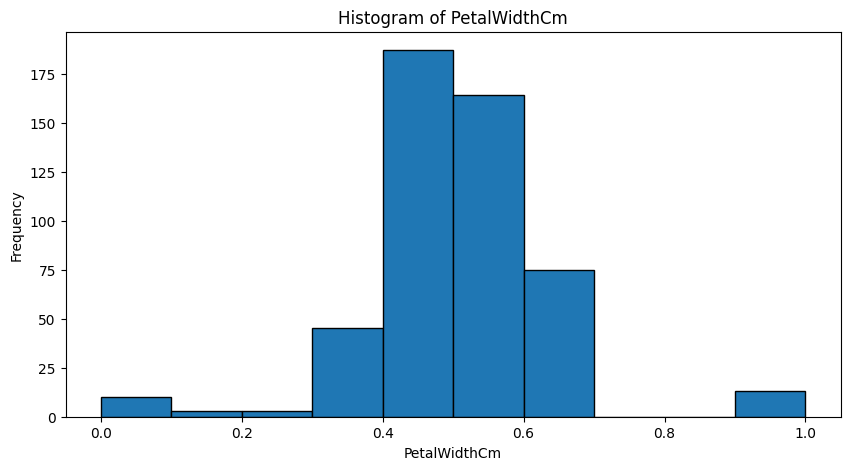

Largest positive correlation feature:
                  Feature  Pearson_r
26  PetalWidthCompactness   0.991670
25   PetalWidthElongation   0.991551
28    PetalWidthCurvature   0.991273
23    PetalWidthMajorAxis   0.991141
27       PetalWidthSpread   0.991095

Top 5 strongest negative correlations:
                  Feature  Pearson_r
11    SepalWidthMajorAxis  -0.096350
46        SepalGlossIndex  -0.095200
14  SepalWidthCompactness  -0.088496
16    SepalWidthCurvature  -0.081334
12    SepalWidthMinorAxis  -0.074392


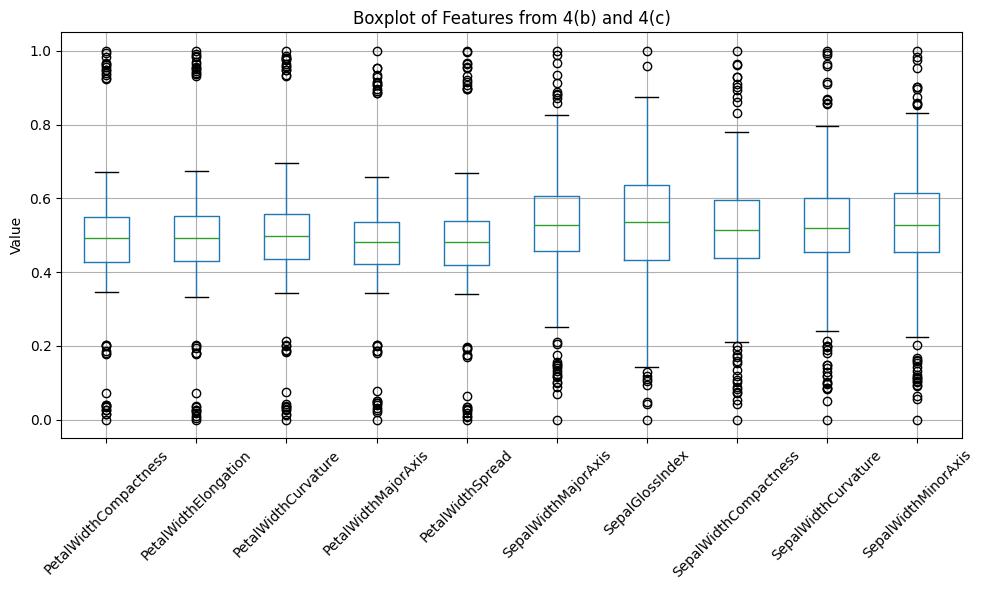

In [19]:
from sklearn.feature_selection import r_regression

# TODO: Complete the 4. Data Exploration
plt.figure(figsize=(10, 5))
plt.hist(df['PetalWidthCm'], edgecolor='black')
plt.xlabel('PetalWidthCm')
plt.ylabel('Frequency')
plt.title('Histogram of PetalWidthCm')
plt.show()

exclude_cols = ['PetalWidthCm', 'Species', 'Id']
feature_cols = [c for c in df.columns if c not in exclude_cols]

scores = r_regression(df[feature_cols], df['PetalWidthCm'])

corr_df = pd.DataFrame({
    'Feature': feature_cols,
    'Pearson_r': scores
})

# 4(b): largest positive correlation
top_positive_feature = corr_df.sort_values('Pearson_r', ascending=False).head(5)
print("Largest positive correlation feature:")
print(top_positive_feature)

# 4(c): top 5 strongest negative correlations
top5_negative = corr_df.sort_values('Pearson_r', ascending=True).head(5)
print("\nTop 5 strongest negative correlations:")
print(top5_negative)


selected_features = top_positive_feature['Feature'].tolist() + top5_negative['Feature'].tolist()

plt.figure(figsize=(10, 6))
df[selected_features].boxplot()
plt.title("Boxplot of Features from 4(b) and 4(c)")
plt.ylabel("Value")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Model Training

### Prepare the data

In [20]:
# Split the data into training and testing sets
from sklearn.model_selection import train_test_split

# normalize the data to [0,1]
for col in feature_cols:
    col_min = df[col].min()
    col_max = df[col].max()
    if col_max > col_min:
        df[col] = (df[col] - col_min) / (col_max - col_min)
    else:
        df[col] = 0.0

X = df[feature_cols].values.astype(float)
y = df['Species'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=seed)

df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,BranchLength,AvgDust,SepalLengthMajorAxis,SepalLengthMinorAxis,SepalLengthElongation,...,LeafHueVariation,CanopyLightCapture,CanopyMoistureSignal,SoilMoistureSignal,AmbientHumiditySignal,ThermalResponseIndex,UVExposureIndex,WindStressIndex,GrowthVigorIndex,Species
0,1,0.606061,0.608,0.482759,0.452830,0.600000,0.376147,0.544026,0.529185,0.548614,...,0.565095,0.580677,0.449986,0.027756,0.419409,0.693758,0.602718,0.589990,0.217516,0
1,2,0.515152,0.680,0.459770,0.471698,0.528571,0.963303,0.464754,0.442295,0.444221,...,0.301642,0.626733,0.259595,0.417482,0.568359,0.384086,0.564410,0.823373,0.459439,0
2,3,0.590909,0.616,0.505747,0.471698,0.600000,0.740061,0.537937,0.530229,0.524031,...,0.579598,0.620325,0.516296,0.668622,0.512741,0.360130,0.282303,0.500461,0.344289,0
3,4,0.378788,0.320,0.527082,0.433962,0.414286,0.604485,0.381672,0.358911,0.332111,...,0.469160,0.573916,0.671291,0.416456,0.392474,0.323568,0.407208,0.623292,0.650231,0
4,5,0.530303,0.520,0.471264,0.471698,0.528571,0.152905,0.478459,0.485877,0.454197,...,0.402983,0.735985,0.377538,0.615546,0.782640,0.816078,0.545727,0.627534,0.574324,0


### Train the model!

50. Training loss: 0.6744470613020765, Val loss:0.6820529903014463
100. Training loss: 0.6755530986968029, Val loss:0.6844380919094257
150. Training loss: 0.6755769220600925, Val loss:0.6844928726169682
200. Training loss: 0.6755774326588768, Val loss:0.6844941296979858
250. Training loss: 0.6755774436412383, Val loss:0.6844941586410452
300. Training loss: 0.6755774438782916, Val loss:0.6844941593095135
350. Training loss: 0.6755774438834254, Val loss:0.6844941593249961
400. Training loss: 0.6755774438835369, Val loss:0.6844941593253557
450. Training loss: 0.6755774438835394, Val loss:0.6844941593253642
500. Training loss: 0.6755774438835395, Val loss:0.6844941593253644
550. Training loss: 0.6755774438835395, Val loss:0.6844941593253644
600. Training loss: 0.6755774438835395, Val loss:0.6844941593253644
650. Training loss: 0.6755774438835395, Val loss:0.6844941593253644
700. Training loss: 0.6755774438835395, Val loss:0.6844941593253644
750. Training loss: 0.6755774438835395, Val loss:

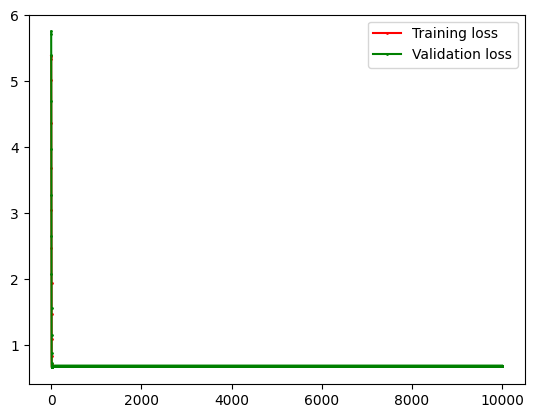

Model parameters (weights): [[-1.16285803e-02]
 [ 2.26772032e-02]
 [ 7.73345223e-03]
 [ 2.21145500e-02]
 [ 1.90942845e-02]
 [ 1.81330886e-02]
 [ 1.82683748e-02]
 [ 1.96102596e-02]
 [ 2.06389794e-02]
 [ 1.95305673e-02]
 [ 2.05359134e-02]
 [ 2.13423009e-02]
 [ 4.99343624e-03]
 [ 3.53007643e-03]
 [ 6.47532111e-03]
 [ 7.45393992e-03]
 [ 7.82613680e-03]
 [ 6.67739797e-03]
 [ 2.37666716e-02]
 [ 2.43367724e-02]
 [ 2.61458902e-02]
 [ 2.44040784e-02]
 [ 2.56923698e-02]
 [ 2.42382684e-02]
 [ 3.52388567e-02]
 [ 3.58399988e-02]
 [ 3.72584951e-02]
 [ 3.71260251e-02]
 [ 3.73318537e-02]
 [ 3.73462976e-02]
 [-1.26321989e-02]
 [ 5.02548526e-03]
 [-5.97509759e-03]
 [-1.99267264e-03]
 [-4.77159959e-03]
 [-2.90915098e-03]
 [-1.20074315e-02]
 [-2.71005004e-02]
 [-4.83912392e-03]
 [-9.38313233e-03]
 [-3.73877585e-03]
 [-1.49375642e-02]
 [-6.54614735e-03]
 [-1.32667536e-03]
 [-5.11898383e-03]
 [-8.21282519e-03]
 [-4.77204460e-03]
 [-1.10225122e-02]
 [-8.41153414e-03]
 [-8.51200393e-04]
 [-7.16350172e-03]
 [-

In [31]:
# Use the LinearModel to fit the data

from model.linear_model import LinearModel
from model.metrics import logloss
from model.gradients import logloss_sigmoid_grad
from model.utils import *
from model.activations import sigmoid

# Model configuration
loss_fn = logloss
act_fn = sigmoid
grad_fn = logloss_sigmoid_grad
data_path = 'images/'
np.random.seed(seed)
r_ld = 100
model = LinearModel(dim=X_train.shape[1], is_reg=False, loss_fn=loss_fn, act_fn=act_fn, grad_fn=grad_fn)
model.fit(X_train, y_train,lr=0.1, n_iteration =10000,val_ratio=0.2, reg_type='l2', reg_lambda=r_ld,data_path=data_path+str(r_ld))

# print model parameters
print("Model parameters (weights):", model.W)
# sum of absolute values of weights
print("Sum of absolute values of weights:", np.sum(np.abs(model.W)))

## Metrics

Model Evaluation
MSE       : 0.4933
MAE       : 0.4933
RMSE      : 0.7024
R-squared : -0.9737


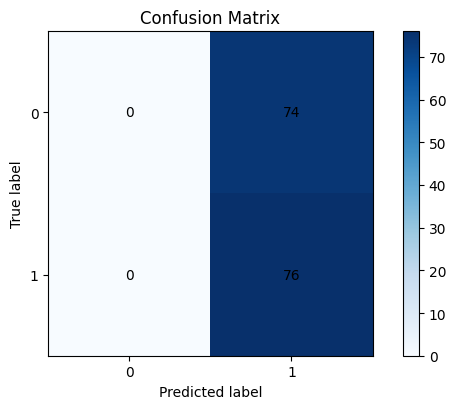

{'MSE': 0.49333333333333335,
 'MAE': 0.49333333333333335,
 'RMSE': np.float64(0.7023769168568492),
 'R-squared': -0.9736842105263159}

In [32]:
# use evaluate_binary_classifier to evaluate the model on the test set
from model.metrics import evaluate_binary_classifier

y_pred = model.predict(X_test)
evaluate_binary_classifier(y_test, y_pred,data_path=data_path+str(r_ld))